In [21]:
# ============================================================
# INSTALL REQUIRED PACKAGE
# ============================================================

!pip install tsplib95

In [22]:
# ============================================================
# BLOCK 1 — IMPORTS
# ============================================================

import random
import time
import numpy as np
import matplotlib.pyplot as plt
import tsplib95

from google.colab import files

In [23]:
# ============================================================
# BLOCK 2 — CONFIGURATION
# ============================================================

POP_SIZE = 70
MAX_GENERATIONS = 300
TOURNAMENT_SIZE = 4
MUTATION_RATE = 0.20
ELITE_COUNT = 2
SEED = 1

rng = random.Random(SEED)

In [24]:
# ============================================================
# BLOCK 3 — LOAD TSPLIB INSTANCE
# ============================================================

uploaded = files.upload()

path = list(uploaded.keys())[0]

problem = tsplib95.load(path)

nodes = list(problem.get_nodes())
n = len(nodes)

index = {node: i for i, node in enumerate(nodes)}

print(f"Loaded instance with {n} cities")

Saving berlin52.tsp to berlin52 (3).tsp
Loaded instance with 52 cities


In [25]:
# ============================================================
# BLOCK 4 — DISTANCE MATRIX
# ============================================================

dist = np.zeros((n, n), dtype=np.float64)

for a in nodes:

    ia = index[a]

    for b in nodes:

        ib = index[b]

        if a != b:
            dist[ia, ib] = problem.get_weight(a, b)

print("Distance matrix created.")

Distance matrix created.


In [26]:
# ============================================================
# BLOCK 5 — BASIC UTILITIES
# ============================================================

def tour_length(tour):

    return sum(
        dist[tour[i], tour[(i + 1) % n]]
        for i in range(n)
    )


def fitness(cost):

    return 1.0 / cost


def valid_tour(tour):

    return (
        len(tour) == n
        and len(set(tour)) == n
    )

In [27]:
# ============================================================
# BLOCK 6 — INITIAL POPULATION
# ============================================================

def random_tour():

    tour = list(range(n))

    rng.shuffle(tour)

    return tour


population = [
    random_tour()
    for _ in range(POP_SIZE)
]

print(f"Initial population size: {len(population)}")

Initial population size: 70


In [28]:
# ============================================================
# BLOCK 7 — TOURNAMENT SELECTION
# ============================================================

def tournament_selection(population):

    candidates = rng.sample(
        population,
        TOURNAMENT_SIZE
    )

    return min(
        candidates,
        key=tour_length
    )

In [29]:
# ============================================================
# BLOCK 8 — ORDERED CROSSOVER (OX)
# ============================================================

def ordered_crossover(parent1, parent2):

    i, j = sorted(
        rng.sample(range(n), 2)
    )

    child = [None] * n

    child[i:j + 1] = parent1[i:j + 1]

    remaining = [
        city for city in parent2
        if city not in child
    ]

    ptr = 0

    for k in range(n):

        if child[k] is None:

            child[k] = remaining[ptr]

            ptr += 1

    return child

In [30]:
# ============================================================
# BLOCK 9 — SWAP MUTATION
# ============================================================

def swap_mutation(tour):

    child = tour[: ]

    i, j = rng.sample(range(n), 2)

    child[i], child[j] = child[j], child[i]

    return child

In [31]:
# ============================================================
# BLOCK 10 — MAIN GENETIC ALGORITHM
# ============================================================

start_time = time.time()

best_tour = min(population, key=tour_length)
best_cost = tour_length(best_tour)

history = [best_cost]

print(f"Initial Best Cost: {best_cost:,.2f}")

for generation in range(1, MAX_GENERATIONS + 1):

    ranked = sorted(population, key=tour_length)

    new_population = []

    # --------------------------------------------------------
    # ELITISM
    # --------------------------------------------------------
    for elite in ranked[:ELITE_COUNT]:
        new_population.append(elite[:])

    # --------------------------------------------------------
    # CREATE OFFSPRING
    # --------------------------------------------------------
    while len(new_population) < POP_SIZE:

        parent1 = tournament_selection(population)
        parent2 = tournament_selection(population)

        child = ordered_crossover(parent1, parent2)

        if rng.random() < MUTATION_RATE:
            child = swap_mutation(child)

        new_population.append(child)

    population = new_population

    # --------------------------------------------------------
    # TRACK BEST SOLUTION
    # --------------------------------------------------------
    generation_best = min(population, key=tour_length)
    generation_best_cost = tour_length(generation_best)

    if generation_best_cost < best_cost:

        best_cost = generation_best_cost
        best_tour = generation_best[: ]

        print(
            f"Generation {generation:03d} | "
            f"New Best Cost = {best_cost:,.2f}"
        )

    history.append(best_cost)

# ------------------------------------------------------------
# COMPUTATION TIME
# ------------------------------------------------------------

end_time = time.time()

runtime = end_time - start_time

Initial Best Cost: 26,537.00
Generation 001 | New Best Cost = 25,668.00
Generation 002 | New Best Cost = 23,276.00
Generation 003 | New Best Cost = 23,177.00
Generation 004 | New Best Cost = 22,055.00
Generation 005 | New Best Cost = 21,290.00
Generation 007 | New Best Cost = 20,633.00
Generation 008 | New Best Cost = 19,881.00
Generation 010 | New Best Cost = 19,492.00
Generation 011 | New Best Cost = 19,083.00
Generation 012 | New Best Cost = 18,749.00
Generation 013 | New Best Cost = 17,790.00
Generation 014 | New Best Cost = 17,576.00
Generation 015 | New Best Cost = 17,362.00
Generation 016 | New Best Cost = 16,742.00
Generation 018 | New Best Cost = 16,432.00
Generation 019 | New Best Cost = 16,276.00
Generation 020 | New Best Cost = 16,210.00
Generation 021 | New Best Cost = 15,941.00
Generation 022 | New Best Cost = 15,543.00
Generation 023 | New Best Cost = 15,519.00
Generation 024 | New Best Cost = 15,203.00
Generation 027 | New Best Cost = 14,861.00
Generation 028 | New Best

In [33]:
# ============================================================
# BLOCK 11 — FINAL RESULT
# ============================================================

print("\n" + "=" * 60)
print("STANDARD GENETIC ALGORITHM RESULT")
print("=" * 60)

print(f"Best Cost        : {best_cost:,.2f}")
print(f"Best Tour        : {best_tour}")
print(f"Generations      : {MAX_GENERATIONS}")
print(f"Population Size  : {POP_SIZE}")
print(f"Computation Time : {runtime:.4f} seconds")


STANDARD GENETIC ALGORITHM RESULT
Best Cost        : 10,938.00
Best Tour        : [12, 13, 51, 10, 3, 14, 39, 38, 31, 48, 2, 16, 20, 21, 0, 49, 19, 43, 23, 47, 4, 5, 42, 9, 8, 44, 15, 28, 1, 6, 41, 29, 22, 30, 17, 18, 40, 7, 32, 50, 11, 27, 25, 46, 45, 36, 33, 34, 35, 37, 24, 26]
Generations      : 300
Population Size  : 70
Computation Time : 9.2565 seconds


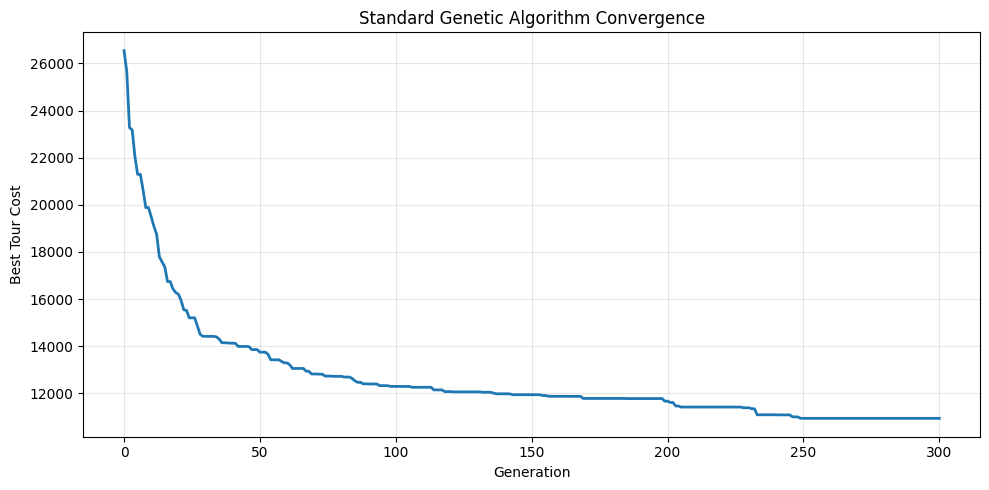

In [34]:
# ============================================================
# BLOCK 12 — CONVERGENCE GRAPH
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(history, linewidth=2)

plt.xlabel("Generation")
plt.ylabel("Best Tour Cost")

plt.title("Standard Genetic Algorithm Convergence")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

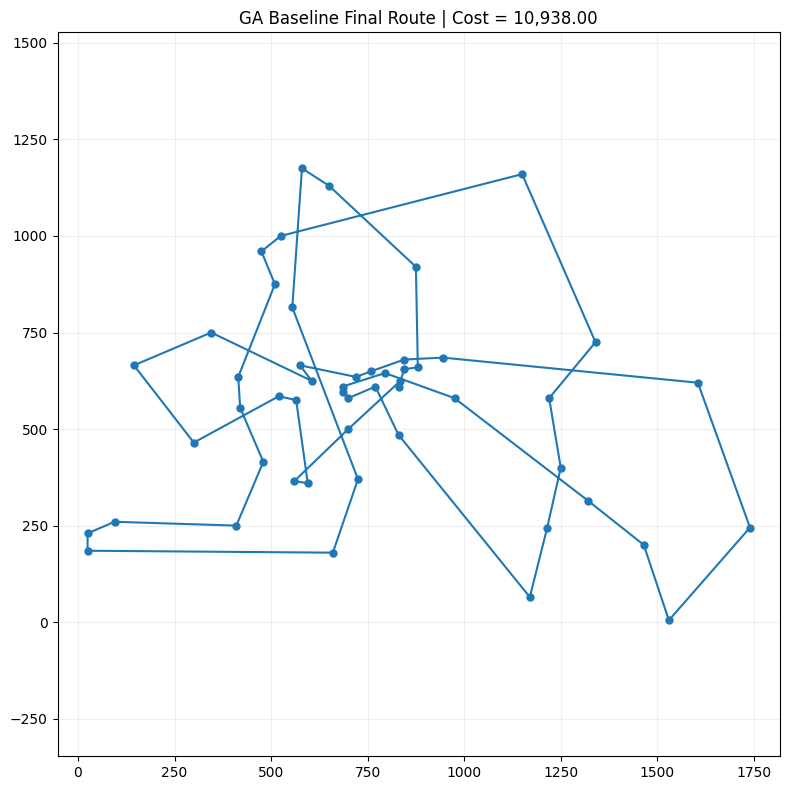

In [35]:
# ============================================================
# BLOCK 13 — FINAL ROUTE VISUALIZATION
# ============================================================

if getattr(problem, "node_coords", None):

    coords = np.array([
        problem.node_coords[node]
        for node in nodes
    ])

    route = best_tour + [best_tour[0]]

    x = [coords[i, 0] for i in route]
    y = [coords[i, 1] for i in route]

    plt.figure(figsize=(8, 8))

    plt.plot(x, y, linewidth=1.5)
    plt.scatter(coords[:, 0], coords[:, 1], s=25)

    plt.title(
        f"GA Baseline Final Route | Cost = {best_cost:,.2f}"
    )

    plt.axis("equal")
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()